<a href="https://colab.research.google.com/github/Ananya-Srinivasan-19/ACY_AAT/blob/main/ACY_AAT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **KNN**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5848 entries, 0 to 5847
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    5848 non-null   int64  
 1   V1      5848 non-null   float64
 2   V2      5848 non-null   float64
 3   V3      5848 non-null   float64
 4   V4      5848 non-null   float64
 5   V5      5848 non-null   float64
 6   V6      5848 non-null   float64
 7   V7      5848 non-null   float64
 8   V8      5848 non-null   float64
 9   V9      5848 non-null   float64
 10  V10     5848 non-null   float64
 11  V11     5848 non-null   float64
 12  V12     5848 non-null   float64
 13  V13     5848 non-null   float64
 14  V14     5848 non-null   float64
 15  V15     5848 non-null   float64
 16  V16     5848 non-null   float64
 17  V17     5848 non-null   float64
 18  V18     5848 non-null   float64
 19  V19     5848 non-null   float64
 20  V20     5848 non-null   float64
 21  V21     5848 non-null   float64
 22  

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


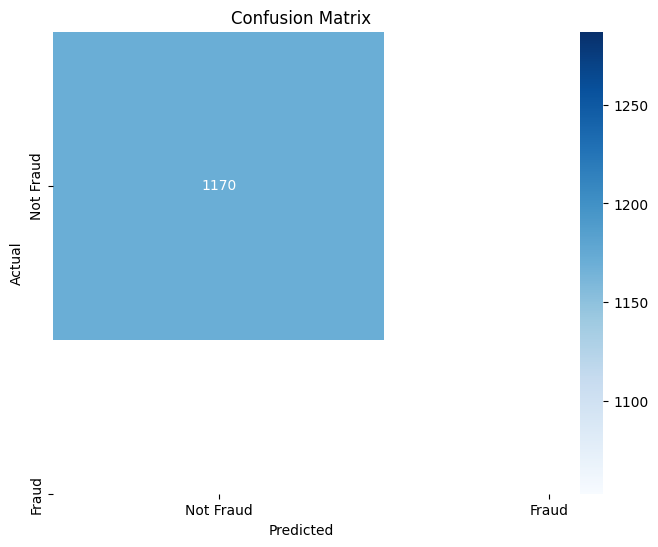

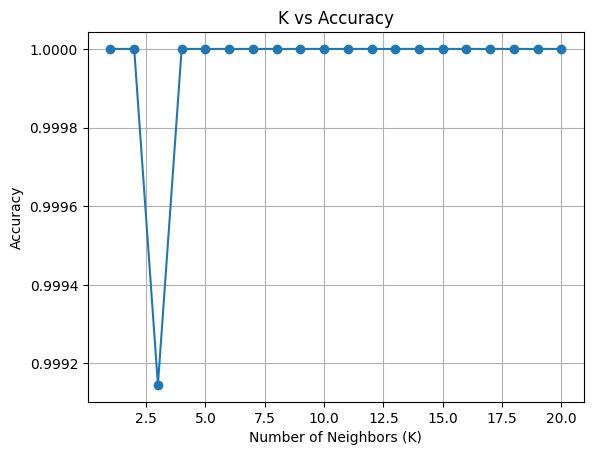

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
# Import SimpleImputer for handling missing values
from sklearn.impute import SimpleImputer


# Step 1: Load the dataset
# Assuming you're using a dataset like the "Credit Card Fraud Detection" from Kaggle
data = pd.read_csv('creditcard.csv')

# Step 2: Explore the data
print(data.info())  # Check for missing values and data types
print(data.describe())  # Get summary statistics

# Step 3: Preprocess the data
# Separate the features (X) and the target variable (y)
X = data.drop(['Class'], axis=1)  # Exclude the 'Class' column which is the target
y = data['Class']  # 'Class' column is the target variable (fraud=1, not fraud=0)

# ***Handle Missing Values in Target (y)***
# Drop rows with missing values in the target variable
# You might need to adapt this if you want to impute instead of dropping
data = data.dropna(subset=['Class'])
X = data.drop(['Class'], axis=1)
y = data['Class']


# Impute missing values using the mean for features (X)
# Create an imputer object with strategy 'mean'
imputer = SimpleImputer(strategy='mean')

# Fit the imputer on your training data and transform it
X = imputer.fit_transform(X)

# Normalize the features (important for KNN performance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Step 4: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Step 5: Train the KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Step 6: Make predictions
y_pred = knn.predict(X_test)

# Step 7: Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Fraud", "Fraud"], yticklabels=["Not Fraud", "Fraud"])
plt.title("Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Step 8: (Optional) Find the best K value (Hyperparameter Tuning)
# You can experiment with different values of K to see which one gives the best performance
neighbors = list(range(1, 21))
accuracies = []

for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    accuracies.append(knn.score(X_test, y_test))

# Plot K vs Accuracy
plt.plot(neighbors, accuracies, marker='o')
plt.title("K vs Accuracy")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

# **RANDOM FOREST**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

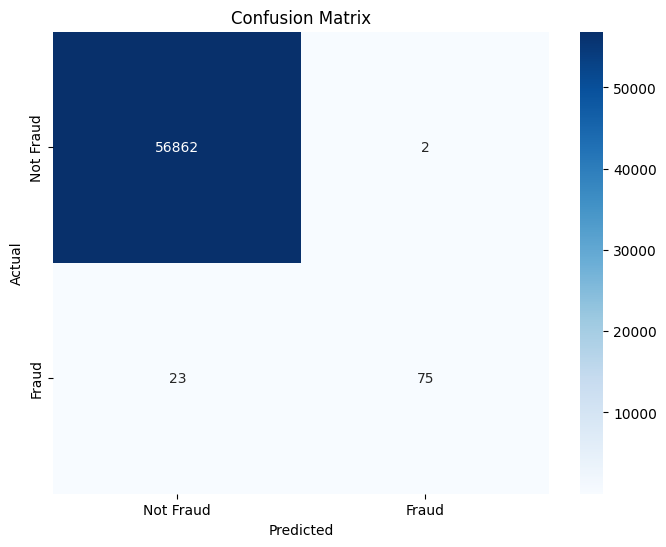

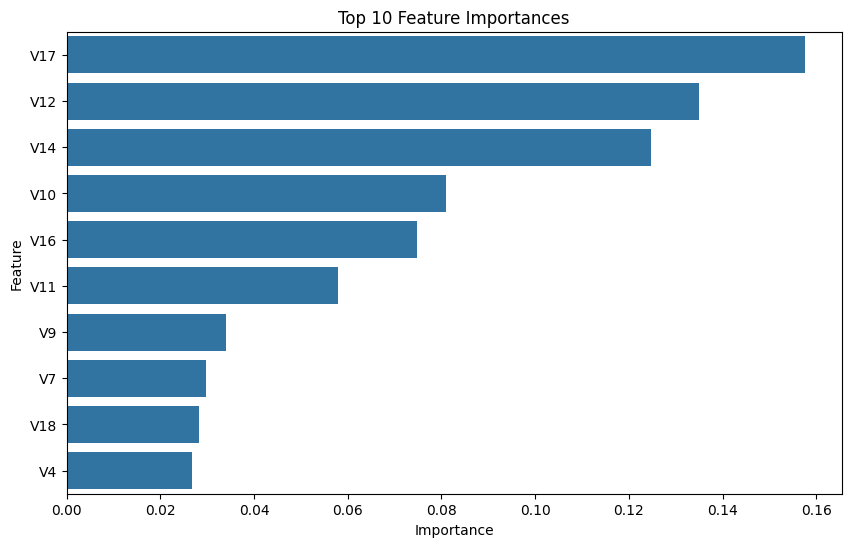

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the dataset
# Assuming you're using a dataset like the "Credit Card Fraud Detection" from Kaggle
data = pd.read_csv('creditcard.csv')

# Step 2: Explore the data
print(data.info())  # Check for missing values and data types
print(data.describe())  # Get summary statistics

# Step 3: Preprocess the data
# Separate the features (X) and the target variable (y)
X = data.drop(['Class'], axis=1)  # Exclude the 'Class' column which is the target
y = data['Class']  # 'Class' column is the target variable (fraud=1, not fraud=0)

# Normalize the features (important for improving Random Forest performance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Step 5: Train the Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Step 6: Make predictions
y_pred = rf.predict(X_test)

# Step 7: Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Fraud", "Fraud"], yticklabels=["Not Fraud", "Fraud"])
plt.title("Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Step 8: Feature Importance (Optional)
# Random Forest can be used to check the importance of each feature
feature_importances = rf.feature_importances_

# Create a DataFrame to display feature importances
features = X.columns
feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the top 10 important features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Feature Importances')
plt.show()


## **XG BOOST**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [08:16:49] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.97      0.78      0.86        98

    accuracy                           1.00     56962
   macro avg       0.99      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962



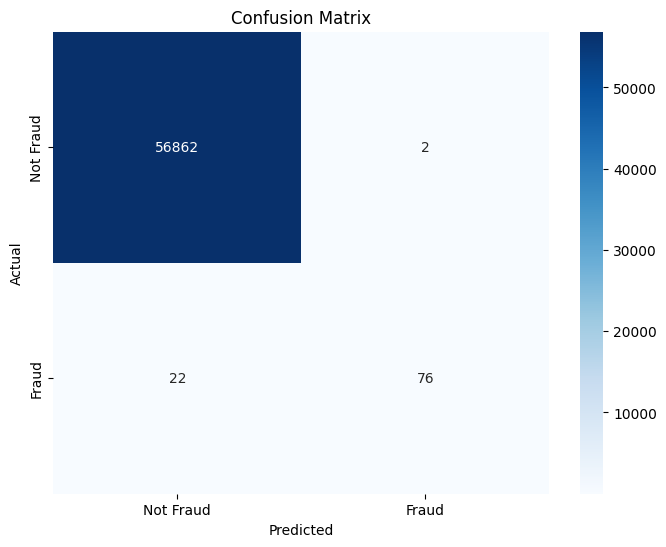

<Figure size 1000x600 with 0 Axes>

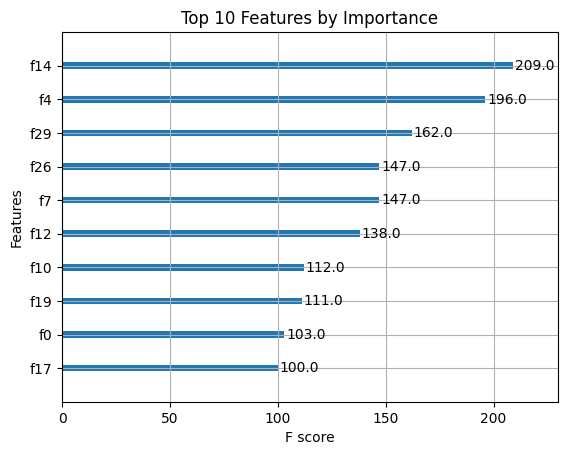

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Load the dataset
# Assuming you're using a dataset like the "Credit Card Fraud Detection" from Kaggle
data = pd.read_csv('creditcard.csv')

# Step 2: Explore the data
print(data.info())  # Check for missing values and data types
print(data.describe())  # Get summary statistics

# Step 3: Preprocess the data
# Separate the features (X) and the target variable (y)
X = data.drop(['Class'], axis=1)  # Exclude the 'Class' column which is the target
y = data['Class']  # 'Class' column is the target variable (fraud=1, not fraud=0)

# Normalize the features (important for gradient boosting algorithms)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Step 5: Train the XGBoost Classifier
# Define the model with basic parameters
xgb_model = xgb.XGBClassifier(
    n_estimators=100,       # Number of trees
    learning_rate=0.1,      # Step size for each iteration
    max_depth=6,            # Maximum depth of the tree
    random_state=42,        # For reproducibility
    use_label_encoder=False, # Suppress warnings
    eval_metric='logloss'   # Evaluation metric
)

# Train the model
xgb_model.fit(X_train, y_train)

# Step 6: Make predictions
y_pred = xgb_model.predict(X_test)

# Step 7: Evaluate the model
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Fraud", "Fraud"], yticklabels=["Not Fraud", "Fraud"])
plt.title("Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Step 8: Feature Importance (Optional)
# XGBoost provides a built-in feature importance plot
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, max_num_features=10, importance_type='weight', title='Top 10 Features by Importance')
plt.show()
